# **Project of finding survivors of a catastrophical encouter with ice**

**Firstly we of course add default libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

**Now we open the titanic data set**

In [3]:
%pip install kagglehub
import kagglehub

# Download latest version
path = kagglehub.competition_download('titanic')

print("Path to competition files:", path)

Note: you may need to restart the kernel to use updated packages.
Path to competition files: C:\Users\bakug\.cache\kagglehub\competitions\titanic


In [4]:
train=pd.read_csv(path + '/train.csv')
print(train.columns)
test=pd.read_csv(path + '/test.csv')
print(test.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')
Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


In [5]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**We successfully read the train and test data and now we will explore it and check for nulls and duplicates**

In [10]:
print(train.info())
print("Train duplicated sum: ",train.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
Train duplicated sum:  0


In [14]:
print(test.info())
print("Test duplicated sum: ",test.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB
None
Test duplicated sum:  0


**Basic statistics of train, test data 1-numerical(int) 2-text(object)**

In [12]:
print(train.describe())
print(test.describe())

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  
       PassengerId      Pclass         Age       SibSp       Parch        Fare
co

In [13]:
print(train.describe(include=['O']))
print(test.describe(include=['O']))

                           Name   Sex  Ticket    Cabin Embarked
count                       891   891     891      204      889
unique                      891     2     681      147        3
top     Braund, Mr. Owen Harris  male  347082  B96 B98        S
freq                          1   577       7        4      644
                    Name   Sex    Ticket            Cabin Embarked
count                418   418       418               91      418
unique               418     2       363               76        3
top     Kelly, Mr. James  male  PC 17608  B57 B59 B63 B66        S
freq                   1   266         5                3      270


**We can see that few columns have huge amount of nulls and a few columns have all unique values, so we will do something about it.**

**Columns Passenger_id and Cabin (as it is mostly nulls) won't be necessary, so we will delete it**

In [46]:
train.drop(columns=['PassengerId','Cabin'], inplace=True)
test.drop(columns=['PassengerId','Cabin'], inplace=True)
print(train.columns)
print(test.columns)

Index(['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket',
       'Fare', 'Embarked'],
      dtype='object')
Index(['Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare',
       'Embarked'],
      dtype='object')


**Now we will visiualize how different colums affect survival rate**

**Age to Survived**

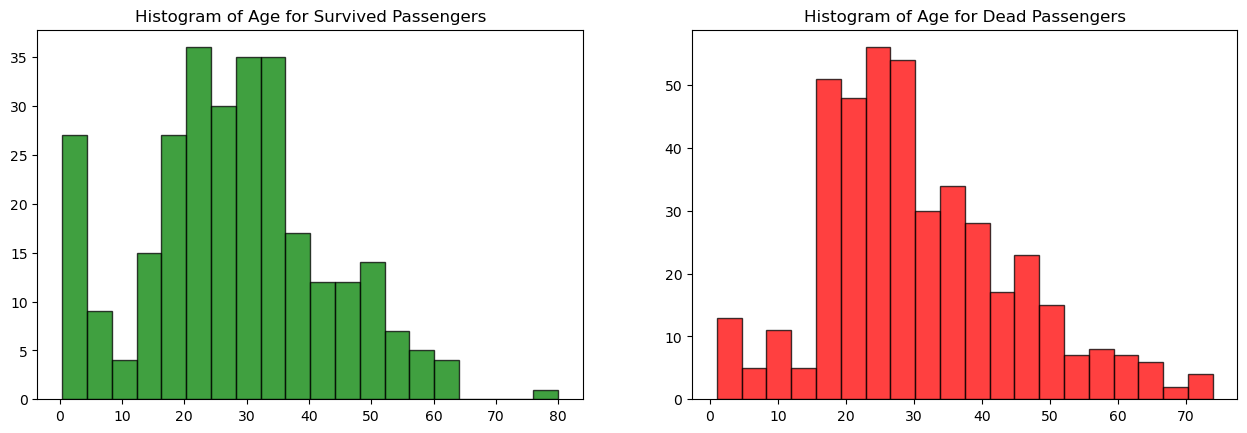

In [47]:
fig, axes = plt.subplots(nrows=1, ncols=2)
axes[0].hist(
    train.loc[train['Survived'] == 1, 'Age'].dropna(),
    bins=20,
    color='green',
    edgecolor='black',
    alpha=0.75,
)
axes[1].hist(
    train.loc[train['Survived'] == 0, 'Age'].dropna(),
    bins=20,
    color='red',
    edgecolor='black',
    alpha=0.75,
)

axes[1].set_title('Histogram of Age for Dead Passengers')
axes[0].set_title('Histogram of Age for Survived Passengers')
plt.subplots_adjust(right=2)
plt.show()

**We can observe that highest survival rate is for children below age 10 and that most people over the age of 65 didn't survive.**

**Pclass to survived (1st - highest class, 3rd - lowest class)**

Pclass
1    136
2     87
3    119
Name: Survived, dtype: int64


ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (891,) and arg 1 with shape (3,).

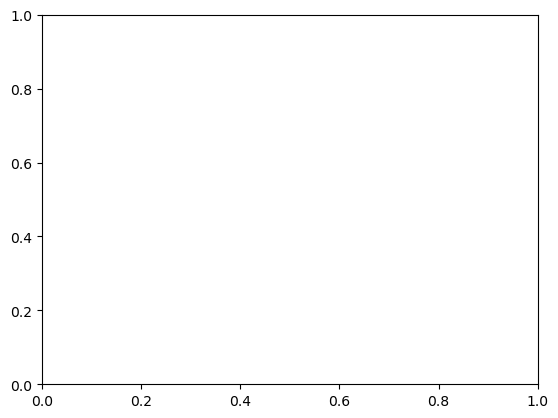

In [ ]:
surv_per_class = train.loc[train['Survived'] == 1, 'Pclass'].value_counts().sort_index()

print(surv_per_class)

plt.bar(surv_per_class.index, surv_per_class.values, edgecolor='black', alpha=0.75)
plt.xlabel('Passenger Class')
plt.ylabel('Number of survivors')
plt.title('Survivors by Passenger Class')
plt.show()